**Chapter 15 – Processing Sequences Using RNNs and CNNs**

_This notebook contains all the sample code in chapter 15._

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/ageron/handson-ml2/blob/master/15_processing_sequences_using_rnns_and_cnns.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

# Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures. We also check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn ≥0.20 and TensorFlow ≥2.0.

In [54]:
!conda create -n keras-core python=3.8
!conda activate keras-core
!pip install keras-core

/bin/bash: line 1: conda: command not found
/bin/bash: line 1: conda: command not found


In [55]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras_core as keras
# from sklearn.metrics import accuracy_score

import torch

In [ ]:
!pip install -q keras-nightly
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import tensorflow as tf
import numpy as np

In [56]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# Common imports
import numpy as np
import os
from pathlib import Path

# to make this notebook's output stable across runs
np.random.seed(42)
torch.manual_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "rnn"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [57]:
def plot_learning_curves111(loss, val_loss):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

In [58]:
def plot_learning_curves(loss, val_loss):
    plt.plot(torch.arange(len(loss)).cpu().numpy() + 0.5, loss.cpu().numpy(), "b.-", label="Training loss")
    plt.plot(torch.arange(len(val_loss)).cpu().numpy() + 1, val_loss.cpu().numpy(), "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

In [59]:
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(torch.arange(n_steps, n_steps + ahead), Y[0, :, 0], "ro-", label="Actual")
    plt.plot(torch.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)


# Basic RNNs

### Generate the Dataset

In [60]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = torch.rand(4, batch_size, 1)
    time = torch.linspace(0, 1, n_steps)
    series = 0.5 * torch.sin((time - offsets1) * (freq1 * 10 + 10))  # wave 1
    series += 0.2 * torch.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (torch.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., None].type(torch.float32) # same as series[..., np.newaxis].astype(np.float32) in numpy

In [61]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [62]:
X_train.shape, y_train.shape

(torch.Size([7000, 50, 1]), torch.Size([7000, 1]))

Saving figure time_series_plot


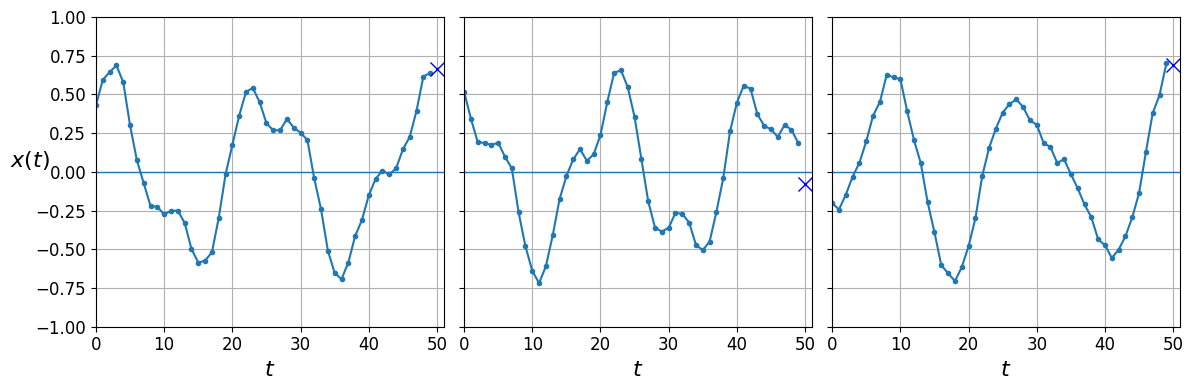

In [63]:
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bx", markersize=10)
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "ro")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])

fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None))
save_fig("time_series_plot")
plt.show()

### Computing Some Baselines

Naive predictions (just predict the last observed value):

In [64]:
y_pred = X_valid[:, -1]
torch.mean(keras.losses.mean_squared_error(y_valid, y_pred))

tensor(0.0207)

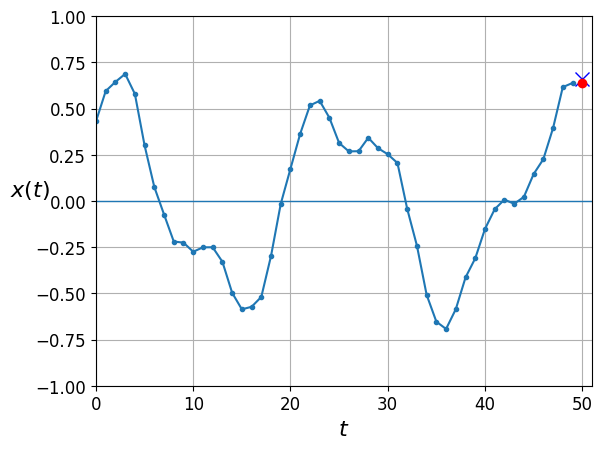

In [65]:
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

Linear predictions:

In [66]:
np.random.seed(42)
torch.manual_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2578 - val_loss: 0.0425
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0340 - val_loss: 0.0215
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0188 - val_loss: 0.0152
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0139 - val_loss: 0.0121
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0116 - val_loss: 0.0105
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0097 - val_loss: 0.0094
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0086 - val_loss: 0.0087
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0078 - val_loss: 0.0077
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0072 - val_loss: 0.0071
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0066 - val_loss: 0.0067
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0062 - val_loss: 0.0061
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/s

In [67]:
model.evaluate(X_valid, y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0047


0.004471711348742247

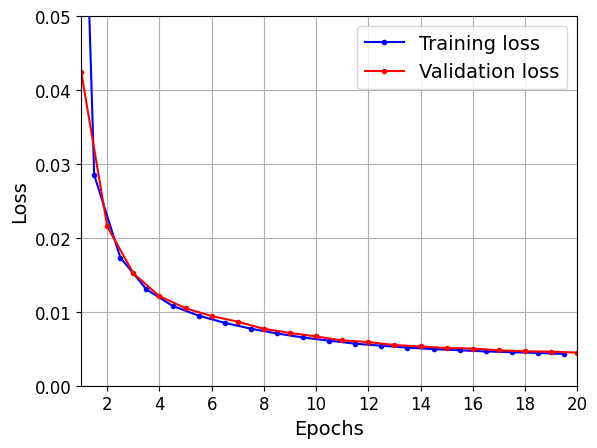

In [68]:
def plot_learning_curves(loss, val_loss):
    plt.plot(torch.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(torch.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)


plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


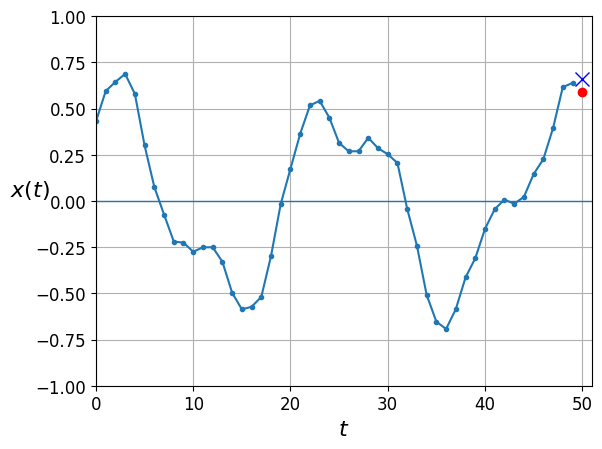

In [69]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

### Using a Simple RNN

In [70]:
np.random.seed(42)
torch.manual_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

optimizer = keras.optimizers.Adam(learning_rate=0.005)
model.compile(loss="mse", optimizer=optimizer)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.1446 - val_loss: 0.0593
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0390 - val_loss: 0.0150
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.0141 - val_loss: 0.0133
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0127 - val_loss: 0.0125
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 0.0119 - val_loss: 0.0120
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0115 - val_loss: 0.0118
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0114 - val_loss: 0.0117
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0109 - val_loss: 0.0117
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.0111 - val_loss: 0.0117
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0111 - val_loss: 0.0118
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0112 - val_loss: 0.0116
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━

In [71]:
model.evaluate(X_valid, y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0121


0.011830732226371765

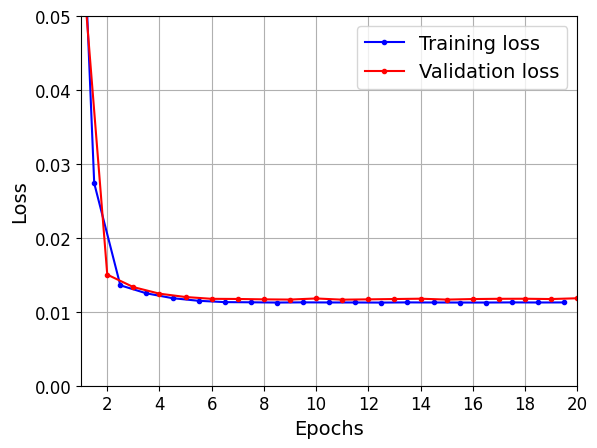

In [72]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


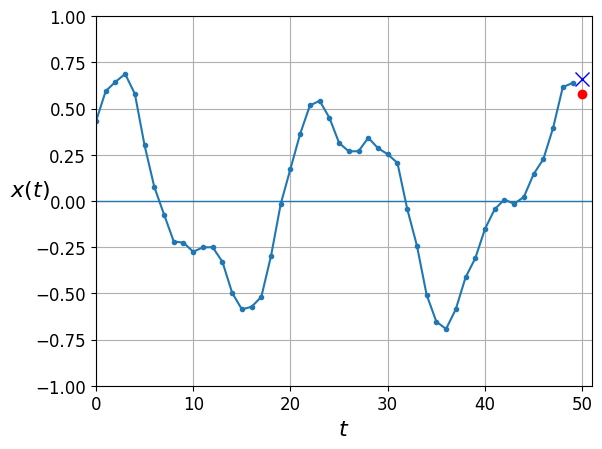

In [73]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

## Deep RNNs

In [75]:
np.random.seed(42)
torch.manual_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
  1/219 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - loss: 0.3610

/usr/local/lib/python3.10/dist-packages/keras_core/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 125ms/step - loss: 0.0849 - val_loss: 0.0083
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - loss: 0.0071 - val_loss: 0.0054
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - loss: 0.0050 - val_loss: 0.0047
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 129ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 121ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 124ms/step - loss: 0.0035 - val_loss: 0.0042
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - loss: 0.0034 - val_loss: 0.0038
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - loss: 0.0034 - val_loss: 0.0038
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 26s 121ms/step - loss: 0.0034 - val_loss: 0.0050
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 130ms/step - loss: 0.0034 - val_loss: 0.0033
Epoch 12/20
219/219 ━━━━━━━━━━

In [76]:
model.evaluate(X_valid, y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0029


0.002844194183126092

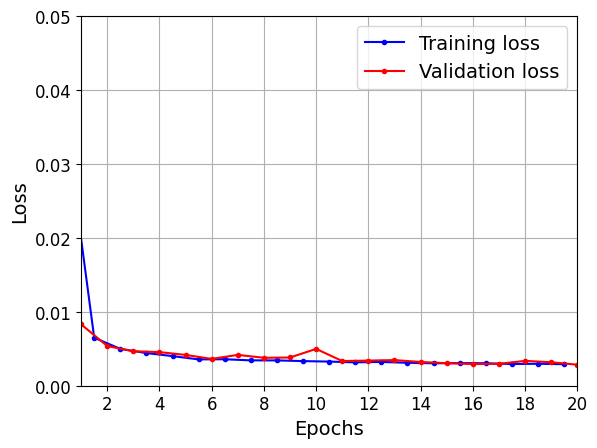

In [77]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step


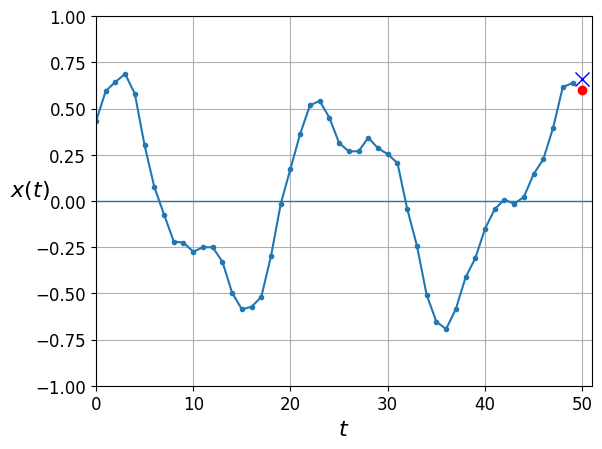

In [78]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

Make the second `SimpleRNN` layer return only the last output:

In [79]:
np.random.seed(42)
torch.manual_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - loss: 0.0853 - val_loss: 0.0053
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - loss: 0.0047 - val_loss: 0.0040
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - loss: 0.0038 - val_loss: 0.0041
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 0.0032 - val_loss: 0.0037
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.0032 - val_loss: 0.0041
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 12/20
219/219 ━━━━━━━━━━

In [80]:
model.evaluate(X_valid, y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0029


0.002893151016905904

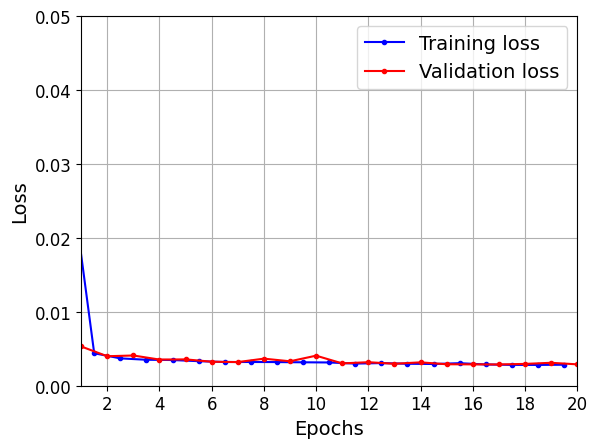

In [81]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step


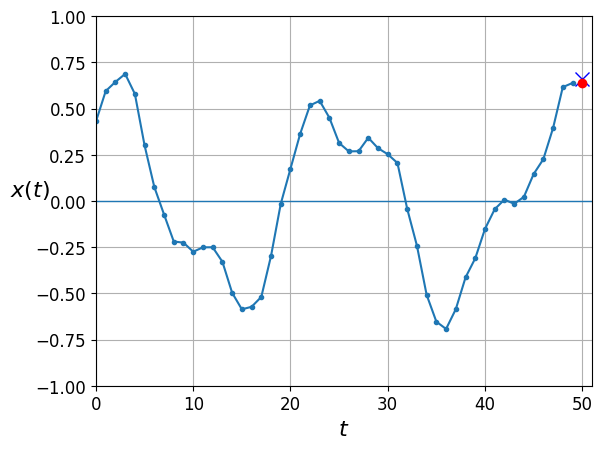

In [82]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

## Forecasting Several Steps Ahead

In [83]:
np.random.seed(43) # not 42, as it would give the first series in the train set

series = generate_time_series(1, n_steps + 10)
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]
X = X_new
for step_ahead in range(10):
    y_pred_one = model.predict(X[:, step_ahead:])[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [84]:
Y_pred.shape

(1, 10, 1)

Saving figure forecast_ahead_plot


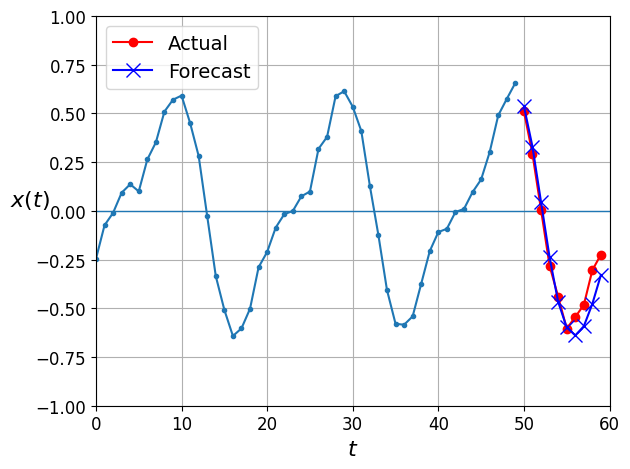

In [85]:
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "ro-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

plot_multiple_forecasts(X_new, Y_new, Y_pred)
save_fig("forecast_ahead_plot")
plt.show()

Now let's use this model to predict the next 10 values. We first need to regenerate the sequences with 9 more time steps.

In [86]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train, Y_train = series[:7000, :n_steps], series[:7000, -10:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -10:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -10:, 0]

Now let's predict the next 10 values one by one:

In [87]:
X = X_valid
for step_ahead in range(10):
    y_pred_one = model.predict(X)[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:, 0]

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step


In [88]:
Y_pred.shape

(2000, 10)

Let's compare this performance with some baselines: naive predictions and a simple linear model:

In [90]:
torch.mean(keras.losses.mean_squared_error(Y_valid, Y_pred))


tensor(0.0315)

In [92]:
Y_naive_pred = Y_valid[:, -1:]
torch.mean(keras.losses.mean_squared_error(Y_valid, Y_naive_pred))

tensor(0.2219)

In [93]:
np.random.seed(42)
torch.manual_seed(42)

model_seq = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(10)
])

model_seq.compile(loss="mse", optimizer="adam")
history = model_seq.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
 53/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3537

/usr/local/lib/python3.10/dist-packages/keras_core/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2438 - val_loss: 0.0728
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0645 - val_loss: 0.0472
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0439 - val_loss: 0.0381
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0365 - val_loss: 0.0333
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0322 - val_loss: 0.0303
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0297 - val_loss: 0.0282
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0279 - val_loss: 0.0265
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0259 - val_loss: 0.0251
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0246 - val_loss: 0.0241
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0240 - val_loss: 0.0233
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0234 - val_loss: 0.0227
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0

In [94]:
model_seq.evaluate(X_test, Y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0188        


0.018968436866998672

Now let's create an RNN that predicts all 10 next values at once:

In [95]:
np.random.seed(42)
torch.manual_seed(42)

model_rnn = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10)
])

model_rnn.compile(loss="mse", optimizer="adam")
history = model_rnn.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
  2/219 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - loss: 0.6422

/usr/local/lib/python3.10/dist-packages/keras_core/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - loss: 0.1699 - val_loss: 0.0410
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - loss: 0.0379 - val_loss: 0.0261
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - loss: 0.0234 - val_loss: 0.0200
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - loss: 0.0187 - val_loss: 0.0158
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0162 - val_loss: 0.0159
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 0.0150 - val_loss: 0.0166
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - loss: 0.0157 - val_loss: 0.0131
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0130 - val_loss: 0.0118
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - loss: 0.0125 - val_loss: 0.0146
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0127 - val_loss: 0.0110
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - loss: 0.0122 - val_loss: 0.0134
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━

In [96]:
model_rnn.evaluate(X_test, Y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0096


0.009343543089926243

In [99]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, -10:, :]
Y_pred = model_rnn.predict(X_new)[..., np.newaxis]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


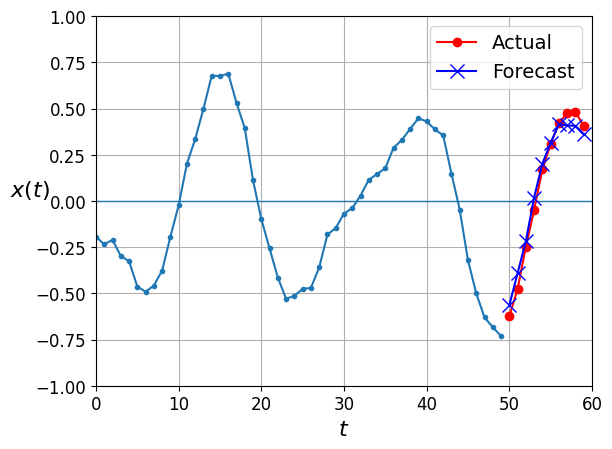

In [100]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

Now let's create an RNN that predicts the next 10 steps at each time step. That is, instead of just forecasting time steps 50 to 59 based on time steps 0 to 49, it will forecast time steps 1 to 10 at time step 0, then time steps 2 to 11 at time step 1, and so on, and finally it will forecast time steps 50 to 59 at the last time step. Notice that the model is causal: when it makes predictions at any time step, it can only see past time steps.

In [104]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]
Y = np.empty((10000, n_steps, 10))
for step_ahead in range(1, 10 + 1):
    Y[..., step_ahead - 1] = series[..., step_ahead:step_ahead + n_steps, 0]
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

In [105]:
X_train.shape, Y_train.shape

(torch.Size([7000, 50, 1]), (7000, 50, 10))

In [106]:
np.random.seed(42)
torch.manual_seed(42)

model_td = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

def last_time_step_mse(Y_true, Y_pred):
    return keras.losses.mean_squared_error(Y_true[:, -1], Y_pred[:, -1])

model_td.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.01), metrics=[last_time_step_mse])
history = model_td.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

/usr/local/lib/python3.10/dist-packages/keras_core/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - loss: 0.0692 - mean_metric_wrapper: 0.0597 - val_loss: 0.0446 - val_mean_metric_wrapper: 0.0347
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - loss: 0.0411 - mean_metric_wrapper: 0.0288 - val_loss: 0.0345 - val_mean_metric_wrapper: 0.0219
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - loss: 0.0345 - mean_metric_wrapper: 0.0217 - val_loss: 0.0309 - val_mean_metric_wrapper: 0.0188
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - loss: 0.0311 - mean_metric_wrapper: 0.0183 - val_loss: 0.0296 - val_mean_metric_wrapper: 0.0181
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - loss: 0.0286 - mean_metric_wrapper: 0.0161 - val_loss: 0.0266 - val_mean_metric_wrapper: 0.0141
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - loss: 0.0268 - mean_metric_wrapper: 0.0146 - val_loss: 0.0260 - val_mean_metric_wrapper: 0.0138
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - loss: 0.0253 - mean_metric

In [107]:
model_td.evaluate(X_test, Y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0182 - mean_metric_wrapper: 0.0070


[0.018195929005742073, 0.00698457146063447]

In [108]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model_td.predict(X_new)[:, -1][..., np.newaxis]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


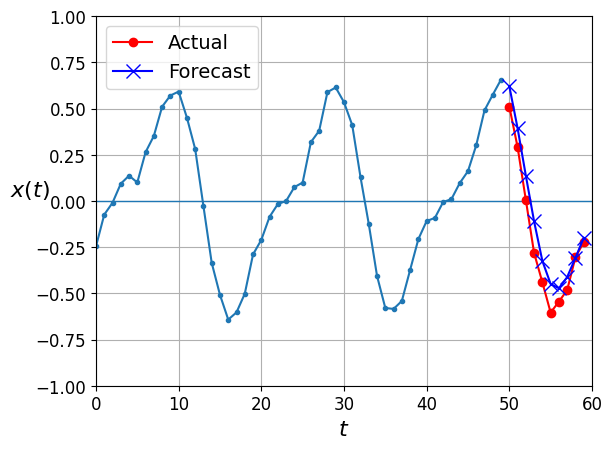

In [109]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

# Deep RNN with Batch Norm

In [110]:
np.random.seed(42)
torch.manual_seed(42)

model_bn = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.BatchNormalization(),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.BatchNormalization(),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model_bn.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model_bn.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras_core/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - loss: 0.3236 - mean_metric_wrapper_1: 0.3159 - val_loss: 0.0645 - val_mean_metric_wrapper_1: 0.0582
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - loss: 0.0509 - mean_metric_wrapper_1: 0.0417 - val_loss: 0.0495 - val_mean_metric_wrapper_1: 0.0411
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - loss: 0.0449 - mean_metric_wrapper_1: 0.0354 - val_loss: 0.0426 - val_mean_metric_wrapper_1: 0.0330
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - loss: 0.0407 - mean_metric_wrapper_1: 0.0306 - val_loss: 0.0405 - val_mean_metric_wrapper_1: 0.0313
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - loss: 0.0379 - mean_metric_wrapper_1: 0.0269 - val_loss: 0.0360 - val_mean_metric_wrapper_1: 0.0248
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - loss: 0.0357 - mean_metric_wrapper_1: 0.0238 - val_loss: 0.0343 - val_mean_metric_wrapper_1: 0.0227
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - loss: 0.0340

In [111]:
model_bn.evaluate(X_test, Y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0276 - mean_metric_wrapper_1: 0.0141


[0.02724769152700901, 0.013978168368339539]

# LSTMs

Now let's use this model to predict the next 10 values. We first need to regenerate the sequences with 9 more time steps.

In [133]:
#Already defined; included for an easier reload
#Same as before...
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]
Y = torch.empty((10000, n_steps, 10))
for step_ahead in range(1, 10 + 1):
    Y[..., step_ahead - 1] = series[..., step_ahead:step_ahead + n_steps, 0]
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

In [136]:
def last_time_step_mse(Y_true, Y_pred):
    return (keras.losses.mean_squared_error(Y_true[:, -1], Y_pred[:, -1]))


In [137]:
np.random.seed(42)
torch.manual_seed(42)

model = keras.models.Sequential([
    keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras_core/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape                  ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                      │ (None, None, 20)              │       1,760 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ lstm_3 (LSTM)                      │ (None, None, 20)              │       3,280 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ time_distributed_6                 │ (None, None, 10)              │         210 │
│ (TimeDistributed)                  │                               │             │
└────────────────────────────────────┴───────────────────────────────┴─────────────┘

 Total params: 5,250 (20.51 KB)

 Trainable params: 5,250 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

In [138]:
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 152ms/step - loss: 0.1030 - mean_metric_wrapper_3: 0.0935 - val_loss: 0.0535 - val_mean_metric_wrapper_3: 0.0340
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 152ms/step - loss: 0.0499 - mean_metric_wrapper_3: 0.0303 - val_loss: 0.0411 - val_mean_metric_wrapper_3: 0.0197
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 150ms/step - loss: 0.0390 - mean_metric_wrapper_3: 0.0188 - val_loss: 0.0353 - val_mean_metric_wrapper_3: 0.0155
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 35s 159ms/step - loss: 0.0344 - mean_metric_wrapper_3: 0.0151 - val_loss: 0.0341 - val_mean_metric_wrapper_3: 0.0163
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 150ms/step - loss: 0.0319 - mean_metric_wrapper_3: 0.0131 - val_loss: 0.0303 - val_mean_metric_wrapper_3: 0.0118
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 34s 156ms/step - loss: 0.0302 - mean_metric_wrapper_3: 0.0121 - val_loss: 0.0291 - val_mean_metric_wrapper_3: 0.0121
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 149ms/step - l

In [126]:
model.evaluate(X_valid, Y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0227 - mean_metric_wrapper_2: 0.0085


[0.022695267572999, 0.008489702828228474]

In [127]:
model.evaluate(X_test, Y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 0.0227 - mean_metric_wrapper_2: 0.0084


[0.022758208215236664, 0.00817817822098732]

In [140]:
np.random.seed(42)
torch.manual_seed(42)

model = keras.models.Sequential([
    keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.Dense(10)
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape                  ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                      │ (None, None, 20)              │       1,760 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ lstm_5 (LSTM)                      │ (None, None, 20)              │       3,280 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ dense_14 (Dense)                   │ (None, None, 10)              │         210 │
└────────────────────────────────────┴───────────────────────────────┴─────────────┘

 Total params: 5,250 (20.51 KB)

 Trainable params: 5,250 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

In [141]:
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 141ms/step - loss: 0.1024 - mean_metric_wrapper_4: 0.0929 - val_loss: 0.0537 - val_mean_metric_wrapper_4: 0.0333
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 143ms/step - loss: 0.0501 - mean_metric_wrapper_4: 0.0300 - val_loss: 0.0410 - val_mean_metric_wrapper_4: 0.0210
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 148ms/step - loss: 0.0389 - mean_metric_wrapper_4: 0.0180 - val_loss: 0.0352 - val_mean_metric_wrapper_4: 0.0149
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 30s 139ms/step - loss: 0.0346 - mean_metric_wrapper_4: 0.0148 - val_loss: 0.0327 - val_mean_metric_wrapper_4: 0.0139
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - loss: 0.0323 - mean_metric_wrapper_4: 0.0138 - val_loss: 0.0306 - val_mean_metric_wrapper_4: 0.0121
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 145ms/step - loss: 0.0305 - mean_metric_wrapper_4: 0.0123 - val_loss: 0.0296 - val_mean_metric_wrapper_4: 0.0129
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 140ms/step - l

In [142]:
model.evaluate(X_valid, Y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0233 - mean_metric_wrapper_4: 0.0083


[0.023293979465961456, 0.008311049081385136]

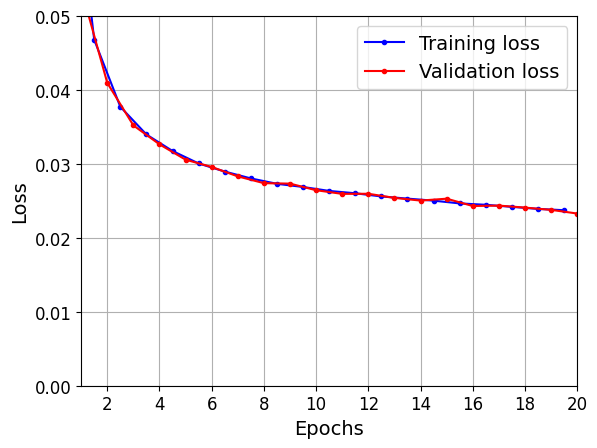

In [143]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [144]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


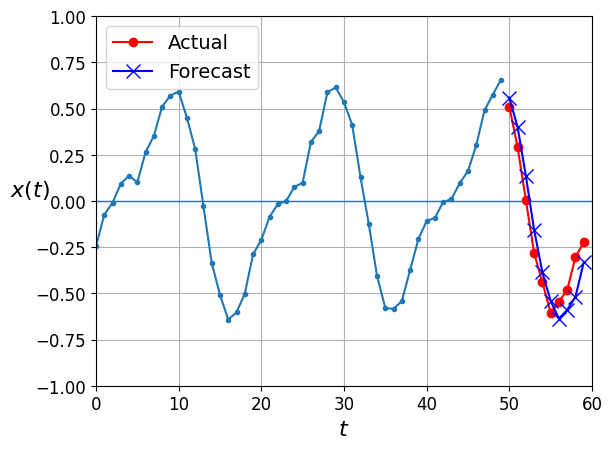

In [145]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

# GRUs

In [146]:
np.random.seed(42)
torch.manual_seed(42)

model = keras.models.Sequential([
    keras.layers.GRU(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape                  ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ gru (GRU)                          │ (None, None, 20)              │       1,380 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ gru_1 (GRU)                        │ (None, None, 20)              │       2,520 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ time_distributed_7                 │ (None, None, 10)              │         210 │
│ (TimeDistributed)                  │                               │             │
└────────────────────────────────────┴───────────────────────────────┴─────────────┘

 Total params: 4,110 (16.05 KB)

 Trainable params: 4,110 (16.05 KB)

 Non-trainable params: 0 (0.00 B)

In [147]:

history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 188ms/step - loss: 0.1001 - mean_metric_wrapper_5: 0.0943 - val_loss: 0.0551 - val_mean_metric_wrapper_5: 0.0452
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 185ms/step - loss: 0.0519 - mean_metric_wrapper_5: 0.0418 - val_loss: 0.0461 - val_mean_metric_wrapper_5: 0.0368
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 42s 191ms/step - loss: 0.0448 - mean_metric_wrapper_5: 0.0345 - val_loss: 0.0431 - val_mean_metric_wrapper_5: 0.0330
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 185ms/step - loss: 0.0423 - mean_metric_wrapper_5: 0.0318 - val_loss: 0.0395 - val_mean_metric_wrapper_5: 0.0292
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 186ms/step - loss: 0.0390 - mean_metric_wrapper_5: 0.0278 - val_loss: 0.0353 - val_mean_metric_wrapper_5: 0.0236
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 47s 214ms/step - loss: 0.0346 - mean_metric_wrapper_5: 0.0225 - val_loss: 0.0316 - val_mean_metric_wrapper_5: 0.0192
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 184ms/step - l

In [148]:
model.evaluate(X_valid, Y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0234 - mean_metric_wrapper_5: 0.0106


[0.023231670260429382, 0.010594622232019901]

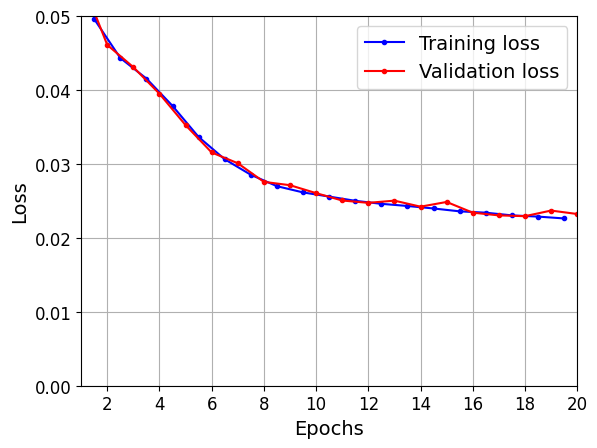

In [149]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [150]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred = model.predict(X_new)[:, -1][..., np.newaxis]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


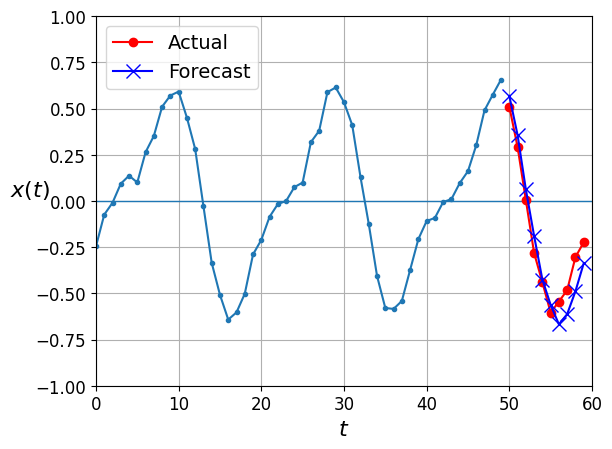

In [151]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

## Using One-Dimensional Convolutional Layers to Process Sequences

```
1D conv layer with kernel size 4, stride 2, VALID padding:

              |-----2-----|     |-----5---...------|     |-----23----|
        |-----1-----|     |-----4-----|   ...      |-----22----|
  |-----0----|      |-----3-----|     |---...|-----21----|
X: 0  1  2  3  4  5  6  7  8  9  10 11 12 ... 42 43 44 45 46 47 48 49
Y: 1  2  3  4  5  6  7  8  9  10 11 12 13 ... 43 44 45 46 47 48 49 50
  /10 11 12 13 14 15 16 17 18 19 20 21 22 ... 52 53 54 55 56 57 58 59

Output:

X:     0/3   2/5   4/7   6/9   8/11 10/13 .../43 42/45 44/47 46/49
Y:     4/13  6/15  8/17 10/19 12/21 14/23 .../53 46/55 48/57 50/59
```

In [152]:
np.random.seed(42)
torch.manual_seed(42)

model = keras.models.Sequential([
    keras.layers.Conv1D(filters=20, kernel_size=4, strides=2, padding="valid",
                        input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train[:, 3::2], epochs=20,
                    validation_data=(X_valid, Y_valid[:, 3::2]))

/usr/local/lib/python3.10/dist-packages/keras_core/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - loss: 0.0905 - mean_metric_wrapper_6: 0.0841 - val_loss: 0.0443 - val_mean_metric_wrapper_6: 0.0370
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - loss: 0.0405 - mean_metric_wrapper_6: 0.0336 - val_loss: 0.0349 - val_mean_metric_wrapper_6: 0.0282
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 26s 117ms/step - loss: 0.0328 - mean_metric_wrapper_6: 0.0253 - val_loss: 0.0307 - val_mean_metric_wrapper_6: 0.0228
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - loss: 0.0292 - mean_metric_wrapper_6: 0.0205 - val_loss: 0.0269 - val_mean_metric_wrapper_6: 0.0165
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - loss: 0.0261 - mean_metric_wrapper_6: 0.0159 - val_loss: 0.0246 - val_mean_metric_wrapper_6: 0.0139
Epoch 6/20
 33/219 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0249 - mean_metric_wrapper_6: 0.0143

KeyboardInterrupt: 

## WaveNet

```
C2  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\.../\ /\ /\ /\ /\ /\
   \  /  \  /  \  /  \  /  \  /  \  /  \       /  \  /  \  /  \
     /    \      /    \      /    \                 /    \
C1  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\  /\ /.../\ /\ /\ /\ /\ /\ /\
X: 0  1  2  3  4  5  6  7  8  9  10 11 12 ... 43 44 45 46 47 48 49
Y: 1  2  3  4  5  6  7  8  9  10 11 12 13 ... 44 45 46 47 48 49 50
  /10 11 12 13 14 15 16 17 18 19 20 21 22 ... 53 54 55 56 57 58 59
```

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=[None, 1]))
for rate in (1, 2, 4, 8) * 2:
    model.add(keras.layers.Conv1D(filters=20, kernel_size=2, padding="causal",
                                  activation="relu", dilation_rate=rate))
model.add(keras.layers.Conv1D(filters=10, kernel_size=1))
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Here is the original WaveNet defined in the paper: it uses Gated Activation Units instead of ReLU and parametrized skip connections, plus it pads with zeros on the left to avoid getting shorter and shorter sequences:

In [ ]:
class GatedActivationUnit(keras.layers.Layer):
    def __init__(self, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.activation = keras.activations.get(activation)
    def call(self, inputs):
        n_filters = inputs.shape[-1] // 2
        linear_output = self.activation(inputs[..., :n_filters])
        gate = keras.activations.sigmoid(inputs[..., n_filters:])
        return self.activation(linear_output) * gate

In [ ]:
def wavenet_residual_block(inputs, n_filters, dilation_rate):
    z = keras.layers.Conv1D(2 * n_filters, kernel_size=2, padding="causal",
                            dilation_rate=dilation_rate)(inputs)
    z = GatedActivationUnit()(z)
    z = keras.layers.Conv1D(n_filters, kernel_size=1)(z)
    return keras.layers.Add()([z, inputs]), z

In [ ]:
keras.backend.clear_session()
np.random.seed(42)
torch.manual_seed(42)

n_layers_per_block = 3 # 10 in the paper
n_blocks = 1 # 3 in the paper
n_filters = 32 # 128 in the paper
n_outputs = 10 # 256 in the paper

inputs = keras.layers.Input(shape=[None, 1])
z = keras.layers.Conv1D(n_filters, kernel_size=2, padding="causal")(inputs)
skip_to_last = []
for dilation_rate in [2**i for i in range(n_layers_per_block)] * n_blocks:
    z, skip = wavenet_residual_block(z, n_filters, dilation_rate)
    skip_to_last.append(skip)
z = keras.activations.relu(keras.layers.Add()(skip_to_last))
z = keras.layers.Conv1D(n_filters, kernel_size=1, activation="relu")(z)
Y_proba = keras.layers.Conv1D(n_outputs, kernel_size=1, activation="softmax")(z)

model = keras.models.Model(inputs=[inputs], outputs=[Y_proba])

In [ ]:
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=2,
                    validation_data=(X_valid, Y_valid))

In this chapter we explored the fundamentals of RNNs and used them to process sequences (namely, time series). In the process we also looked at other ways to process sequences, including CNNs. In the next chapter we will use RNNs for Natural Language Processing, and we will learn more about RNNs (bidirectional RNNs, stateful vs stateless RNNs, Encoder–Decoders, and Attention-augmented Encoder-Decoders). We will also look at the Transformer, an Attention-only architecture.